# Conditional clade topology sampling: comparing gradient estimators

This notebook demonstrates TreeFlow's **conditional clade distribution** (a
*subsplit Bayesian network*, SBN) over rooted tree topologies, and compares
several gradient estimators for learning its parameters by stochastic gradient
descent.

## Background

A **clade** is a subset of the taxa (the leaves under a node of a rooted tree).
A **subsplit** is the ordered pair of child clades produced when an internal node
splits its parent clade in two. A conditional clade distribution factorises the
probability of a rooted topology over its internal nodes:

$$ P(\tau) = \prod_{v \in \text{internal}(\tau)} P(\text{subsplit}_v \mid \text{clade}_v). $$

Each conditional $P(\cdot \mid C)$ is a categorical over the subsplits of clade
$C$, parametrised by a softmax over a vector of logits. The whole distribution is
therefore differentiable in a single flat logit vector, while *sampling* a
topology is discrete.

## The experiment

We pick a random **target** distribution $p$ (a CCD with known logits) and fit a
**variational** CCD $q$ to it by minimising the reverse KL divergence
$\mathrm{KL}(q \Vert p) = \mathbb{E}_{\tau \sim q}[\log q(\tau) - \log p(\tau)]$.
For small taxon sets we can enumerate every topology, so we have an **exact**
KL (and its exact gradient) to use as ground truth. We compare:

* **Exact gradient** &mdash; differentiate the enumerated KL (ground truth).
* **Score function / REINFORCE** &mdash; with and without a leave-one-out baseline.
* **VIMCO** &mdash; the multi-sample importance-weighted bound.
* **Straight-through Gumbel-Softmax** &mdash; the relaxation / '1-0 probability
  gradient' sampler.


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from treeflow import DEFAULT_FLOAT_DTYPE_TF as FLOAT
from treeflow.conditional_clade.support import ConditionalCladeSupport
from treeflow.conditional_clade.distribution import ConditionalCladeDistribution
from treeflow.conditional_clade.estimators import (
    score_function_surrogate,
    leave_one_out_baseline,
    vimco_surrogate,
    sample_relaxed_cost,
)
# Vectorised graph-op helpers that turn a pre-sampled traversal into the
# differentiable quantities every estimator needs (exact + straight-through).
from treeflow.conditional_clade.traversal_estimators import (
    straight_through_traversal_cost,
)

tf.random.set_seed(0)
np.set_printoptions(precision=3, suppress=True)

## 1. Build the support and a target distribution

We work with `N_TAXA = 5` taxa. The support enumerates every splittable clade and
every subsplit; the number of distinct rooted topologies is the double factorial
$(2n-3)!!$.


In [16]:
N_TAXA = 8
support = ConditionalCladeSupport(N_TAXA, taxon_set=[f't{i}' for i in range(N_TAXA)])

print(f'taxa:                {support.taxon_count}')
print(f'splittable clades:   {support.parent_clade_count}')
print(f'subsplits (logits):  {support.subsplit_count}')
print(f'rooted topologies:   {support.topology_count()}')

taxa:                8
splittable clades:   247
subsplits (logits):  3025
rooted topologies:   135135


The subsplit support also exposes **binary-vector features** for every subsplit
(the membership vectors of the parent and two child clades, concatenated). These
are the hook for an *embedding-based* parametrisation: instead of one free logit
per subsplit, a model could map these features to logits, which scales to taxon
sets where enumerating every subsplit is infeasible.


In [17]:
features = support.subsplit_feature_matrix()
print('subsplit feature matrix shape (M, 3n):', features.shape)
print('first subsplit features [parent | child1 | child2]:')
print(features[0].reshape(3, N_TAXA))

subsplit feature matrix shape (M, 3n): (3025, 24)
first subsplit features [parent | child1 | child2]:
[[1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 1. 1. 1. 1. 1. 1.]]


target distribution over topologies sums to 1.0000000000000004
top-5 topology probabilities: [0.152 0.082 0.022 0.019 0.018]


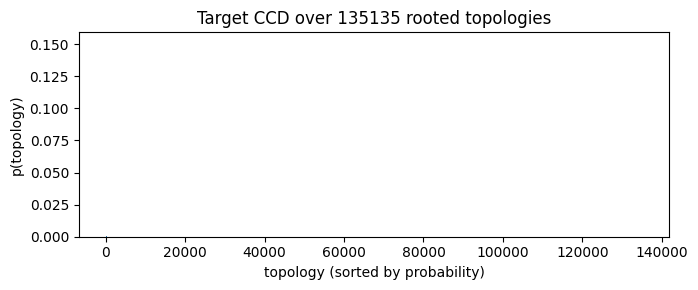

In [18]:
# A random target CCD. Scaling the logits makes the target reasonably peaked.
rng = np.random.default_rng(1)
target_logits = tf.constant(2.0 * rng.standard_normal(support.subsplit_count), FLOAT)
p = ConditionalCladeDistribution(support, target_logits)

target_probs = p.enumerate_probs().numpy()
order = np.argsort(target_probs)[::-1]
print('target distribution over topologies sums to', target_probs.sum())
print('top-5 topology probabilities:', target_probs[order[:5]])

plt.figure(figsize=(7, 3))
plt.bar(range(len(target_probs)), np.sort(target_probs)[::-1])
plt.xlabel('topology (sorted by probability)')
plt.ylabel('p(topology)')
plt.title(f'Target CCD over {support.topology_count()} rooted topologies')
plt.tight_layout(); plt.show()

## 2. Sampling a topology

Sampling walks down from the root clade, drawing a subsplit at each splittable
clade, and converts the result to TreeFlow's `parent_indices` topology encoding
(leaves `0..n-1`, internal nodes `n..2n-2`, root last).


In [19]:
sample_rng = np.random.default_rng(7)
topology = p.sample_topology(sample_rng)
print('parent_indices:', topology.parent_indices)
print('child_indices:\n', topology.child_indices)

# Recover the subsplit assignment and show the clades as taxon sets.
from treeflow.conditional_clade.clade import clade_taxa
assignment = support.parent_indices_to_assignment(topology.parent_indices)
for parent, subsplit in sorted(assignment.items(), key=lambda kv: -bin(kv[0]).count('1')):
    print(f'{clade_taxa(parent)} -> {clade_taxa(subsplit.child1)} | {clade_taxa(subsplit.child2)}')

parent_indices: [ 9 12 12 11  8 13 10  8  9 10 11 14 13 14]
child_indices:
 [[-1 -1]
 [-1 -1]
 [-1 -1]
 [-1 -1]
 [-1 -1]
 [-1 -1]
 [-1 -1]
 [-1 -1]
 [ 4  7]
 [ 0  8]
 [ 6  9]
 [ 3 10]
 [ 1  2]
 [ 5 12]
 [11 13]]
(0, 1, 2, 3, 4, 5, 6, 7) -> (0, 3, 4, 6, 7) | (1, 2, 5)
(0, 3, 4, 6, 7) -> (0, 4, 6, 7) | (3,)
(0, 4, 6, 7) -> (0, 4, 7) | (6,)
(0, 4, 7) -> (0,) | (4, 7)
(1, 2, 5) -> (1, 2) | (5,)
(4, 7) -> (4,) | (7,)
(1, 2) -> (1,) | (2,)


## 3. Estimators

Each estimator returns a gradient of $\mathrm{KL}(q\Vert p)$ with respect to the
variational logits. We use the *surrogate-loss* convention: build a scalar whose
`tf.GradientTape` gradient is the estimator, then read it off.

Every estimator works from the **same pre-sampled traversal**: we draw a batch of
topologies once (the discrete, data-dependent part) and represent each as its
chosen flat subsplit indices. The differentiable quantities are then computed from
that fixed traversal with vectorised graph ops — `log_prob_from_flat_indices` for
the exact score-function family, and `straight_through_traversal_cost` for the
relaxation-based estimator (which replaces the old per-node Python recursion).

In [20]:
def make_q(seed):
    init = np.random.default_rng(seed).standard_normal(support.subsplit_count)
    logits = tf.Variable(tf.constant(init, FLOAT))
    return ConditionalCladeDistribution(support, logits), logits

# Pre-fetch the (constant) target conditional log-probs once.
log_p_cond = p.conditional_log_probs()

def sample_log_probs(q, flat_indices):
    flat = tf.constant(flat_indices, tf.int32)
    log_q = q.log_prob_from_flat_indices(flat)
    log_p = tf.reduce_sum(tf.gather(log_p_cond, flat), axis=-1)
    return log_q, log_p

In [ ]:
def grad_exact(q, logits, rng, batch_size=None):
    with tf.GradientTape() as tape:
        kl = q.exact_kl_divergence(p)
    return tape.gradient(kl, logits)

def grad_score(q, logits, rng, batch_size=64, baseline_state=None):
    flat = q.sample_flat_index_batch(batch_size, rng)
    with tf.GradientTape() as tape:
        log_q, log_p = sample_log_probs(q, flat)
        cost = log_q - log_p
        # constant baseline = batch mean (a simple control variate)
        baseline = tf.reduce_mean(tf.stop_gradient(cost))
        surrogate = score_function_surrogate(cost, log_q, baseline)
    return tape.gradient(surrogate, logits)

def grad_score_loo(q, logits, rng, batch_size=64):
    flat = q.sample_flat_index_batch(batch_size, rng)
    with tf.GradientTape() as tape:
        log_q, log_p = sample_log_probs(q, flat)
        cost = log_q - log_p
        baseline = leave_one_out_baseline(cost)
        surrogate = score_function_surrogate(cost, log_q, baseline)
    return tape.gradient(surrogate, logits)

def grad_straight_through(q, logits, rng, batch_size=64, temperature=0.5):
    # Pre-sample the batch of topologies once (fast, discrete), then compute the
    # straight-through relaxed cost for the whole batch with vectorised graph ops
    # -- no per-node Python recursion, no host syncs. The relaxation is shared
    # between the log q and log p terms (as in the recursive reference).
    flat = tf.constant(q.sample_flat_index_batch(batch_size, rng), tf.int32)
    with tf.GradientTape() as tape:
        cost = straight_through_traversal_cost(
            q.conditional_log_probs(),
            log_p_cond,
            tf.convert_to_tensor(q.logits, FLOAT),
            flat,
            support.segment_ids,
            temperature=temperature,
            gumbel=True,
        )
        loss = tf.reduce_mean(cost)
    return tape.gradient(loss, logits)

def grad_vimco(q, logits, rng, batch_size=64):
    flat = q.sample_flat_index_batch(batch_size, rng)
    with tf.GradientTape() as tape:
        log_q, log_p = sample_log_probs(q, flat)
        log_weights = log_p - log_q
        loss = -vimco_surrogate(log_q, log_weights)  # maximise the bound
    return tape.gradient(loss, logits)

# The reverse-KL estimators (compared head-to-head below). VIMCO targets a
# *different* objective, so it gets its own fair treatment in section 6.
ESTIMATORS = {
    'exact': grad_exact,
    'score function': grad_score,
    'score + leave-one-out': grad_score_loo,
    'straight-through GS': grad_straight_through,
}

## 4. Gradient quality at a fixed point

Before training, we compare each reverse-KL estimator against the exact gradient
at a fixed set of logits. We report:

* **cosine similarity** to the exact (reverse-KL) gradient (direction; the
  score-function estimators are unbiased, so this approaches 1 as we average more
  samples; straight-through is biased), and
* **per-estimate variance** (a proxy for how noisy a single SGD step is).

VIMCO is deliberately excluded here: it ascends a *different* objective (section
6), so measuring its gradient against the exact reverse-KL gradient would be
comparing apples to oranges.

In [22]:
q0, logits0 = make_q(seed=2)
exact = ESTIMATORS['exact'](q0, logits0, None).numpy()

def cosine(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

rng = np.random.default_rng(10)
n_reps = 200
rows = []
for name, fn in ESTIMATORS.items():
    if name == 'exact':
        continue
    grads = np.stack([fn(q0, logits0, rng, batch_size=16).numpy() for _ in range(n_reps)])
    mean_grad = grads.mean(0)
    variance = grads.var(0).sum()              # total variance across logits
    bias = np.linalg.norm(mean_grad - exact)   # 0 for unbiased estimators (in the limit)
    rows.append((name, cosine(mean_grad, exact), variance, bias))

print(f"{'estimator':24s} {'cos(mean, exact)':>16s} {'variance':>12s} {'||bias||':>10s}")
for name, cos, var, bias in rows:
    print(f'{name:24s} {cos:16.3f} {var:12.3f} {bias:10.3f}')

estimator                cos(mean, exact)     variance   ||bias||
score function                      0.930        3.196      0.127
score + leave-one-out               0.922        3.409      0.137
VIMCO                               0.500        6.300      0.296
straight-through GS                 0.878        0.573      0.162


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
names = [r[0] for r in rows]
ax[0].bar(names, [r[2] for r in rows], color='tab:orange')
ax[0].set_ylabel('total gradient variance'); ax[0].set_yscale('log')
ax[0].set_title('Per-step gradient variance (batch=16)')
ax[0].tick_params(axis='x', rotation=30)
ax[1].bar(names, [r[1] for r in rows], color='tab:green')
ax[1].set_ylabel('cosine to exact reverse-KL gradient'); ax[1].set_ylim(0, 1.05)
ax[1].set_title('Direction agreement of the mean estimate')
ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

Both score-function estimators are unbiased for the reverse-KL gradient, so their
mean points in the exact direction; the leave-one-out baseline cuts the variance
of plain REINFORCE. Straight-through Gumbel-Softmax is biased &mdash; its mean does
not match the exact gradient &mdash; but has the lowest variance, which often makes
it competitive in practice. It is now also **cheap**: the relaxed cost is computed
for the whole pre-sampled batch with vectorised graph ops, instead of the old
node-by-node Python recursion (which forced a host&ndash;device sync per node and
was ~10&times; slower).

## 5. Optimisation

Now we actually run SGD with each estimator, tracking the exact
$\mathrm{KL}(q\Vert p)$ (which we can compute because the taxon set is small).


In [ ]:
from tqdm.auto import tqdm

def train(grad_fn, steps=5000, lr=0.05, batch_size=32, seed=2, eval_every=5):
    q, logits = make_q(seed)
    opt = tf.optimizers.Adam(lr)
    rng = np.random.default_rng(100)
    history = []
    for step in tqdm(range(steps)):
        grad = grad_fn(q, logits, rng, batch_size=batch_size)
        opt.apply_gradients([(grad, logits)])
        if step % eval_every == 0:
            history.append((step, float(q.exact_kl_divergence(p).numpy())))
    return np.array(history)

# Same batch size for every estimator now that straight-through is vectorised.
histories = {}
for name, fn in ESTIMATORS.items():
    histories[name] = train(fn, steps=5000, lr=0.05, batch_size=32)
    print(f'{name:24s} final KL = {histories[name][-1, 1]:.4f}')

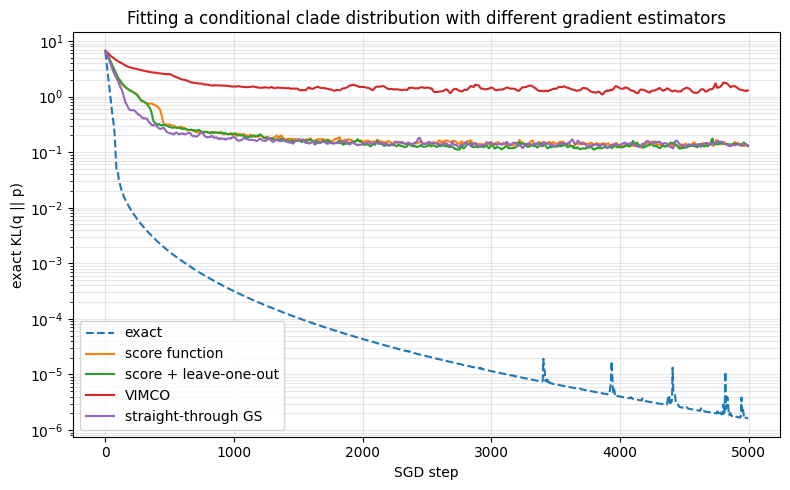

In [31]:
plt.figure(figsize=(8, 5))
for name, hist in histories.items():
    style = '--' if name == 'exact' else '-'
    plt.plot(hist[:, 0], hist[:, 1], style, label=name)
plt.yscale('log')
plt.xlabel('SGD step')
plt.ylabel('exact KL(q || p)')
plt.title('Fitting a conditional clade distribution with different gradient estimators')
plt.legend(); plt.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

**Why do the Monte-Carlo estimators plateau above the exact gradient?** The exact
gradient drives the KL to $\approx 0$, but the stochastic estimators settle on a
*noise floor*. With a fixed learning rate and batch size, SGD with a stochastic
gradient converges to a ball around the optimum whose radius is set by the
gradient variance — it cannot pinpoint the optimum the way the zero-variance exact
gradient does. The floor shrinks with a larger batch (variance $\sim 1/K$) or a
decayed learning rate, and grows with problem size: on this 8-taxon problem (3025
logits, 135135 topologies) it sits around $0.1$; on a 5-taxon problem the same
setup reaches $\approx 0.01$.

## 6. VIMCO optimises a *different* objective

VIMCO does **not** descend the reverse KL the estimators above target — it
*ascends* the $K$-sample importance-weighted bound

$$ \mathcal{L}_K = \mathbb{E}_{\tau_{1:K}\sim q}\Big[\log \tfrac{1}{K}\sum_{k=1}^{K} \frac{p(\tau_k)}{q(\tau_k)}\Big] \;\le\; \log \sum_{\tau} p(\tau) = 0, $$

which is maximised (at $0$) exactly when $q=p$. So on the reverse-KL axis it looks
worse, and its gradient points in a different direction from the exact reverse-KL
gradient (hence the low cosine that would appear in section 4 — that metric is
simply not VIMCO's objective). The right way to see that VIMCO *is* working is to
watch its **own** bound: below we track $\mathcal{L}_K$ (which should climb to
$\approx 0$) alongside the exact reverse KL.

> The implementation is a correct, unbiased estimator of $\nabla\mathcal{L}_K$
> with the standard leave-one-out control variate (its gradient mean matches
> plain REINFORCE-on-the-bound while cutting variance ~10&times;). The reason it
> is the *wrong tool here* is the objective, not a bug: VIMCO is designed for the
> case where $p$ is an **unnormalised** posterior and you want a tight
> marginal-likelihood bound. A characteristic IWAE/VIMCO subtlety (Rainforth et
> al., 2018, *"Tighter Variational Bounds are Not Necessarily Better"*):
> increasing $K$ tightens the bound but *weakens* the signal-to-noise ratio of the
> proposal ($q$) gradient, so a larger $K$ can make the reverse-KL fit **worse** —
> the opposite of what a bug would do.

In [ ]:
def estimate_bound(q, K=32, n_batches=40, seed=0):
    """Monte-Carlo estimate of the K-sample importance-weighted bound L_K.

    L_K = E[ log (1/K sum_k p/q) ] <= 0, maximised (= 0) when q = p.
    """
    g = np.random.default_rng(seed)
    vals = []
    for _ in range(n_batches):
        flat = q.sample_flat_index_batch(K, g)
        log_q, log_p = sample_log_probs(q, flat)
        vals.append(float(tf.reduce_logsumexp(log_p - log_q)) - float(np.log(K)))
    return float(np.mean(vals))

def train_vimco(steps=5000, K=32, lr=0.05, seed=2, eval_every=100):
    q, logits = make_q(seed)
    opt = tf.optimizers.Adam(lr)
    g = np.random.default_rng(100)
    history = []
    for step in tqdm(range(steps)):
        flat = q.sample_flat_index_batch(K, g)
        with tf.GradientTape() as tape:
            log_q, log_p = sample_log_probs(q, flat)
            loss = -vimco_surrogate(log_q, log_p - log_q)  # maximise the bound
        opt.apply_gradients([(tape.gradient(loss, logits), logits)])
        if step % eval_every == 0:
            history.append((step,
                            float(q.exact_kl_divergence(p)),
                            estimate_bound(q, K=K, n_batches=30)))
    return q, np.array(history)

q_vimco, vimco_hist = train_vimco(steps=5000, K=32)
print(f'VIMCO  final reverse KL = {vimco_hist[-1, 1]:.4f}'
      f'   final bound L_K = {estimate_bound(q_vimco, K=32, n_batches=200):+.4f}  (target 0)')

In [ ]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(vimco_hist[:, 0], vimco_hist[:, 1], color='tab:red', label='exact KL(q || p)')
ax1.set_xlabel('SGD step')
ax1.set_ylabel('exact KL(q || p)', color='tab:red')
ax1.set_yscale('log'); ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.plot(vimco_hist[:, 0], vimco_hist[:, 2], color='tab:blue', label='VIMCO bound $L_K$')
ax2.axhline(0.0, color='tab:blue', ls=':', alpha=0.6)
ax2.set_ylabel('VIMCO bound $L_K$   (0 = optimal, $q=p$)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('VIMCO maximises its own bound $L_K \\to 0$, even as reverse KL plateaus higher')
fig.tight_layout(); plt.show()

## 7. Graph-mode tfp distribution over topologies

The eager `ConditionalCladeDistribution` above samples with Python recursion and
NumPy, so it cannot run inside a `tf.function`. `ConditionalCladeTreeDistribution`
is a full `tfp` distribution whose samples are `TensorflowTreeTopology` objects and
whose `sample`/`log_prob` are implemented with `tf.while_loop`, so they trace into
a graph. The discrete, data-dependent topology structure is built with an explicit
two-state depth-first traversal; internal nodes come out in post-order, matching
TreeFlow's `parent_indices` convention.

In [32]:
from treeflow.conditional_clade.tree_distribution import ConditionalCladeTreeDistribution

tree_dist = ConditionalCladeTreeDistribution(support, target_logits)

@tf.function
def sample_and_score(seed):
    topology = tree_dist.sample(5, seed=seed)
    return topology, tree_dist.log_prob(topology)

topology, log_probs = sample_and_score((2024, 7))
print('sample() runs inside tf.function:')
print('  parent_indices shape:', topology.parent_indices.shape)
print('  child_indices shape: ', topology.child_indices.shape)
print('  preorder shape:      ', topology.preorder_indices.shape)
print('  log_prob:            ', log_probs.numpy().round(3))

# Graph-mode log_prob agrees with the eager enumeration and is differentiable.
one_topology = tree_dist.sample(seed=(1, 1))
print('graph log_prob == eager log_prob:',
      np.isclose(float(tree_dist.log_prob(one_topology)),
                 float(p.log_prob(one_topology.parent_indices.numpy()))))

sample() runs inside tf.function:
  parent_indices shape: (5, 14)
  child_indices shape:  (5, 15, 2)
  preorder shape:       (5, 15)
  log_prob:             [-4.145 -4.109 -7.288 -1.887 -6.553]
graph log_prob == eager log_prob: True


## 8. Summary

* TreeFlow now has a differentiable **conditional clade / subsplit** distribution
  over rooted topologies, with exact enumeration, sampling, log-probabilities and
  exact KL for small taxon sets, plus conversion to the standard `parent_indices`
  topology encoding.
* The representation is **embedding-ready**: clades and subsplits expose binary
  membership vectors, so the per-subsplit logits can be produced by a model
  rather than stored explicitly.
* Every gradient estimator works from the **same pre-sampled traversal** plus the
  vectorised graph-op helpers in `traversal_estimators` (no per-node Python):
  * **Score function (REINFORCE)** is unbiased but high variance; a **leave-one-out**
    baseline reduces that variance markedly.
  * **Straight-through Gumbel-Softmax** (the '1-0 probability gradient') is biased
    but lowest variance, and — computed over the pre-sampled batch with graph ops —
    now as cheap as the score-function estimators (~10&times; faster than the
    recursive version).
  * **VIMCO** ascends a *different* objective (the $K$-sample bound $\mathcal{L}_K$,
    optimal at $q=p$): it maximises its own bound to $\approx 0$ (section 6) but, by
    design, does not minimise reverse KL as directly, and a tighter bound (larger
    $K$) weakens the proposal gradient.
* The Monte-Carlo estimators settle on a **noise floor** set by their gradient
  variance; only the zero-variance exact gradient reaches KL $\approx 0$.
* All estimators are compared against the **exact** enumerated gradient, available
  here only because the taxon set is small &mdash; exactly the regime this module is
  designed to support.
* The same model is available as a graph-compatible `tfp` distribution
  (`ConditionalCladeTreeDistribution`) whose `sample`/`log_prob` run inside
  `tf.function` and produce `TensorflowTreeTopology` objects.